# METRIC vs OpenET — 100% GEE Cloud taqqoslash

**Lokal fayllar kerak emas — hamma narsa GEE da.**

### Fazoviy moslik mantiq:
```
METRIC  → WRS-2 tile footprint polygon ichida hisoblangan
OpenET  → CONUS uzluksiz raster (tile tushunchasi yo'q)

Yechim: tile_geometry = WRS-2 polygon = umumiy AOI

METRIC_mean  = et_img.updateMask(CDL).reduceRegion(tile_geometry)
OpenET_mean  = oe_img.updateMask(CDL).reduceRegion(tile_geometry)
                       bir xil polygon → to'g'ri taqqoslash
```
OpenET WRS-2 tile bilmaydi — lekin tile polygon ichidagi qismini reduceRegion bilan so'rash mumkin.

**OpenET modellari (7 ta):** Ensemble, eeMETRIC, disALEXI, geeSEBAL, PT-JPL, SIMS, SSEBop

> OpenET faqat CONUS (Idaho ✅, O'zbekiston ❌)

In [1]:
import ee
import sys, os, calendar, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error

try:
    import seaborn as sns
    sns.set_theme(style='whitegrid', palette='Set2')
    HAS_SNS = True
except ImportError:
    HAS_SNS = False
    print('seaborn yo\'q — conda install seaborn')

plt.rcParams.update({'font.size': 11, 'figure.dpi': 120})
sys.path.insert(0, os.path.abspath('.'))
print('Importlar yuklandi')

seaborn yo'q — conda install seaborn
Importlar yuklandi


## Konfiguratsiya

In [3]:
TILE_PATH = 40
TILE_ROW  = 30

# OpenET CONUS qamrovi: 2016–2023 (ba'zi modellar 2024 gacha)
# 2025 hali yo'q. Quyidagi cell avtomatik eng so'nggi yilni topadi.
# Siz ham qo'lda yozishingiz mumkin: '2023-04' → '2023-10'
COMPARE_MONTHS = [
    '2025-03', '2025-04', '2025-05', '2025-06',
    '2025-07', '2025-08', '2025-09', '2025-10',
]

# CDL_YEAR COMPARE_MONTHS yili bilan mos bo'lsin
CDL_YEAR      = int(COMPARE_MONTHS[0][:4])

CLOUD_MAX     = 50
ROI_CLOUD_MAX = 20
LAPSE_RATE    = 6.5
ETRF_BARE     = 0.05
TIMEZONE_LON  = -105.0
ALBEDO_METHOD = 'olmedo'
SAMPLE_SCALE  = 500

print(f'Tile: P{TILE_PATH:03d}_R{TILE_ROW:03d}')
print(f'Oylar: {COMPARE_MONTHS[0]} dan {COMPARE_MONTHS[-1]} gacha ({len(COMPARE_MONTHS)} oy)')
print(f'CDL yil: {CDL_YEAR}')
print(f'Scale: {SAMPLE_SCALE} m')

Tile: P040_R030
Oylar: 2025-03 dan 2025-10 gacha (8 oy)
CDL yil: 2025
Scale: 500 m


## GEE — Tile geometry va CDL mask

WRS-2 tile footprint polygon = OpenET va METRIC uchun umumiy AOI.

In [4]:
ee.Initialize()

# Tile footprint polygon — OpenET ham shu polygon ichidan so'raladi
tile_geometry = (
    ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
    .filter(ee.Filter.eq('WRS_PATH', TILE_PATH))
    .filter(ee.Filter.eq('WRS_ROW',  TILE_ROW))
    .first()
    .geometry()
)

# CDL cropland mask (1-60 = asosiy ekinlar)
cdl_coll = ee.ImageCollection('USDA/NASS/CDL').filter(
    ee.Filter.calendarRange(CDL_YEAR, CDL_YEAR, 'year'))

crop_mask = None
if cdl_coll.size().getInfo() > 0:
    crop_mask = cdl_coll.first().select('cropland').lte(60)
    frac = (crop_mask
            .reduceRegion(ee.Reducer.mean(), tile_geometry, 500,
                          maxPixels=1e9, bestEffort=True)
            .getInfo().get('cropland', 0))
    print(f'CDL {CDL_YEAR}: qishloq xo\'jaligi {frac*100:.1f}%')
else:
    print(f'CDL {CDL_YEAR} topilmadi — CDL_YEAR o\'zgartiring')

print('GEE initialized')

CDL 2025: qishloq xo'jaligi 18.4%
GEE initialized


## OpenET — 7 model konfiguratsiyasi

In [6]:
# To'g'ri publisher collection IDlar (projects/openet/assets/...)
OPENET_MODELS = {
    'Ensemble': ('projects/openet/assets/ensemble/conus/gridmet/monthly/v2_0', 'et_ensemble_mad'),
    'eeMETRIC': ('projects/openet/assets/eemetric/conus/gridmet/monthly/v2_0', 'et'),
    'disALEXI': ('projects/openet/assets/disalexi/conus/gridmet/monthly/v2_0', 'et'),
    'geeSEBAL': ('projects/openet/assets/geesebal/conus/gridmet/monthly/v2_0', 'et'),
    'PT-JPL':   ('projects/openet/assets/ptjpl/conus/gridmet/monthly/v2_0',    'et'),
    'SIMS':     ('projects/openet/assets/sims/conus/gridmet/monthly/v2_0',     'et'),
    'SSEBop':   ('projects/openet/assets/ssebop/conus/gridmet/monthly/v2_0',   'et'),
}

MODEL_COLORS = {
    'Ensemble': '#2c3e50', 'eeMETRIC': '#27ae60', 'disALEXI': '#2980b9',
    'geeSEBAL': '#8e44ad', 'PT-JPL':   '#e67e22', 'SIMS':     '#c0392b',
    'SSEBop':   '#16a085', 'METRIC':   '#f39c12',
}

# ── OpenET da mavjud eng so'nggi oyni topish ─────────────────────
ref_cid = 'projects/openet/assets/ensemble/conus/gridmet/monthly/v2_0'

openet_latest_year  = None  # None bilan boshlash kerak
openet_latest_month = None  # None bilan boshlash kerak

for yr in range(2026, 2024, -1):  # 2026 dan 1999 gacha tekshiradi
    n = (ee.ImageCollection(ref_cid)
           .filterDate(f'{yr}-01-01', f'{yr+1}-01-01')
           .filterBounds(tile_geometry)
           .size().getInfo())
    if n > 0:
        openet_latest_year = yr
        for mo in range(12, 0, -1):
            end_mo = mo + 1 if mo < 12 else 1
            end_yr = yr if mo < 12 else yr + 1
            n2 = (ee.ImageCollection(ref_cid)
                    .filterDate(f'{yr}-{mo:02d}-01', f'{end_yr}-{end_mo:02d}-01')
                    .filterBounds(tile_geometry)
                    .size().getInfo())
            if n2 > 0:
                openet_latest_month = f'{yr}-{mo:02d}'
                break
        break

if openet_latest_year is None:
    print('OpenET bu tile uchun topilmadi (CONUS emas?)')
else:
    print(f'OpenET qamrovi: 1999-10 → {openet_latest_month}')
    req_year = int(COMPARE_MONTHS[0][:4])
    if req_year > openet_latest_year:
        print(f'COMPARE_MONTHS = {req_year} — OpenET da yo\'q (hali chiqmagan).')
        print(f'  Oxirgi mavjud: {openet_latest_month}')
        COMPARE_MONTHS = [f'{openet_latest_year}-{m[5:]}' for m in COMPARE_MONTHS]
        CDL_YEAR       = openet_latest_year
        print(f'  COMPARE_MONTHS {openet_latest_year} yiliga o\'zgartirildi: {COMPARE_MONTHS[0]} → {COMPARE_MONTHS[-1]}')
        print(f'  CDL_YEAR: {CDL_YEAR}')
    else:
        missing = [m for m in COMPARE_MONTHS if m > openet_latest_month]
        if missing:
            COMPARE_MONTHS = [m for m in COMPARE_MONTHS if m <= openet_latest_month]
            CDL_YEAR = int(COMPARE_MONTHS[0][:4]) if COMPARE_MONTHS else openet_latest_year
            print(f'  Mavjud emas: {missing}')
            print(f'  Yangilangan: {COMPARE_MONTHS}')

# ── CDL maskni yangilangan yil uchun qayta yaratish ──────────────
if CDL_YEAR != int(COMPARE_MONTHS[0][:4]) if COMPARE_MONTHS else False:
    cdl_new = ee.ImageCollection('USDA/NASS/CDL').filter(
        ee.Filter.calendarRange(CDL_YEAR, CDL_YEAR, 'year'))
    if cdl_new.size().getInfo() > 0:
        crop_mask = cdl_new.first().select('cropland').lte(60)
        print(f'  CDL {CDL_YEAR} mask yangilandi')

# ── Har bir model uchun tekshirish ───────────────────────────────
if COMPARE_MONTHS:
    test_year = int(COMPARE_MONTHS[0][:4])
    print(f'\nOpenET modellari ({test_year}):')
    available_models = {}
    for name, (cid, band) in OPENET_MODELS.items():
        try:
            n = (ee.ImageCollection(cid)
                   .filterDate(f'{test_year}-01-01', f'{test_year+1}-01-01')
                   .filterBounds(tile_geometry)
                   .size().getInfo())
            available_models[name] = (n > 0)
            print(f'  {name:10s}: {n} obraz {chr(9989) if n else chr(10060)}')
        except Exception as e:
            available_models[name] = False
            print(f'  {name:10s}: xato — {e}')
    print(f'\nMavjud: {sum(available_models.values())}/7 model')
else:
    print('COMPARE_MONTHS bosh — OpenET da mos oylar topilmadi.')

OpenET bu tile uchun topilmadi (CONUS emas?)

OpenET modellari (2024):
  Ensemble  : 24 obraz ✅
  eeMETRIC  : 24 obraz ✅
  disALEXI  : 24 obraz ✅
  geeSEBAL  : 24 obraz ✅
  PT-JPL    : 24 obraz ✅
  SIMS      : 24 obraz ✅
  SSEBop    : 24 obraz ✅

Mavjud: 7/7 model


## METRIC va OpenET funksiyalari

In [7]:
from pipeline import METRICPipeline
from metric_gee.config.settings import Settings


def month_start_end(month_str):
    year, mo = int(month_str[:4]), int(month_str[5:])
    last = calendar.monthrange(year, mo)[1]
    return f'{year}-{mo:02d}-01', f'{year}-{mo:02d}-{last:02d}'


def run_metric_gee(month_str, geometry, mask=None, scale=SAMPLE_SCALE):
    """METRIC pipeline GEE da ishlaydi, CDL-masked mean qaytaradi."""
    start, end = month_start_end(month_str)
    cfg = Settings(
        cloud_cover_max=CLOUD_MAX, roi_cloud_max=ROI_CLOUD_MAX,
        albedo_method=ALBEDO_METHOD, g_method='bastiaanssen',
        zom_method='lai', lapse_rate=LAPSE_RATE,
        etrf_bare=ETRF_BARE, timezone_lon_deg=TIMEZONE_LON,
        wrs_path=TILE_PATH, wrs_row=TILE_ROW,
    )
    try:
        results = METRICPipeline(settings=cfg).run_monthly(geometry, start, end)
    except Exception as e:
        print(f'    Pipeline xato: {e}')
        return None, None

    if 'error' in results:
        print(f'    {results["error"]}')
        return None, None

    monthly = results.get('monthly_et', {})
    et_img  = monthly.get('et_monthly_image')
    et_all  = monthly.get('et_monthly_mean', 0)

    if et_img is None:
        return et_all, None

    img = et_img.updateMask(mask) if mask is not None else et_img
    val = (img.reduceRegion(
               reducer=ee.Reducer.mean(), geometry=geometry,
               scale=scale, maxPixels=1e10, bestEffort=True
           ).getInfo().get('ET_monthly'))
    return (float(val) if val else et_all), et_img


def get_openet_mean(coll_id, band, month_str, geometry, mask=None, scale=SAMPLE_SCALE):
    """
    OpenET dan tile_geometry ichidagi cropland-only ET mean.
    tile_geometry (WRS-2 polygon) = AOI. OpenET tile bilmaydi,
    lekin shu polygon ichidagi qismini reduceRegion bilan so'raymiz.
    """
    year, mo = int(month_str[:4]), int(month_str[5:])
    start = f'{year}-{mo:02d}-01'
    end   = f'{year}-{mo+1:02d}-01' if mo < 12 else f'{year+1}-01-01'

    coll = ee.ImageCollection(coll_id).filterDate(start, end).filterBounds(geometry)
    if coll.size().getInfo() == 0:
        return None

    img = coll.first().select(band)
    if mask is not None:
        img = img.updateMask(mask)
    val = (img.reduceRegion(
               reducer=ee.Reducer.mean(), geometry=geometry,
               scale=scale, maxPixels=1e10, bestEffort=True
           ).getInfo().get(band))
    return float(val) if val is not None else None


print('Funksiyalar tayyorlandi')

Funksiyalar tayyorlandi


## Ma'lumotlar to'plash — GEE Cloud

> Har oy uchun METRIC ~5-10 daqiqa. 7 oy = 35-70 daqiqa.

In [8]:
records   = []
et_images = {}

for month_str in COMPARE_MONTHS:
    print(f'\n{"="*50}')
    print(f'  {month_str}')
    print('=' * 50)

    print('  METRIC hisoblanyapti...')
    metric_mean, et_img = run_metric_gee(month_str, tile_geometry, mask=crop_mask)
    et_images[month_str] = et_img
    print(f'  METRIC (CDL): {f"{metric_mean:.1f} mm" if metric_mean else "xato"}')

    for model_name, (coll_id, band) in OPENET_MODELS.items():
        val = (get_openet_mean(coll_id, band, month_str, tile_geometry, mask=crop_mask)
               if available_models.get(model_name) else None)
        print(f'  {model_name:10s}: {f"{val:.1f} mm" if val else "yoq"}')
        records.append({'month': month_str, 'model': model_name,
                        'openet': val, 'metric': metric_mean})

df = pd.DataFrame(records)
df['month_dt'] = pd.to_datetime(df['month'] + '-01')
df = df.sort_values(['month', 'model'])

print(f'\nJami: {len(df)} yozuv')
print(df.pivot(index='month', columns='model', values='openet').round(1).to_string())


  2024-03
  METRIC hisoblanyapti...
  WRS filter: Path=40 Row=30
Topilgan tasvirlar: 3
    ✅ Cloud precheck OK: 0.0% (cropland, limit=20%)
  2024-03-09: 2481941 pixels ✅
    ✅ Cloud precheck OK: 1.4% (cropland, limit=20%)
  2024-03-17: 2506860 pixels ✅
    ⚠️  Cloud precheck FAIL: 38.0% (cropland, limit=20%) → skip
  2024-03-25: 2476141 pixels — cloud precheck fail → skip

  --- 2024-03-09 ---
  ┌─ BAND DIAGNOSTIKA ─────────────────────────────────────────
    [Landsat SR (surface reflectance, 0-1)]
      B_BLUE                min=   0.0010  mean=   0.7633  max=   1.0000
      B_GREEN               min=   0.0010  mean=   0.7509  max=   1.0000
      B_RED                 min=   0.0010  mean=   0.7500  max=   1.0000
      B_NIR                 min=   0.0010  mean=   0.7113  max=   1.0000
      B_SWIR1               min=   0.0010  mean=   0.0673  max=   0.7255
      B_SWIR2               min=   0.0010  mean=   0.0708  max=   0.8643
    [Landsat Ts raw (K, birinchi qadam)]
      B_THERMAL

KeyboardInterrupt: 

## 1 — Oylik bar chart

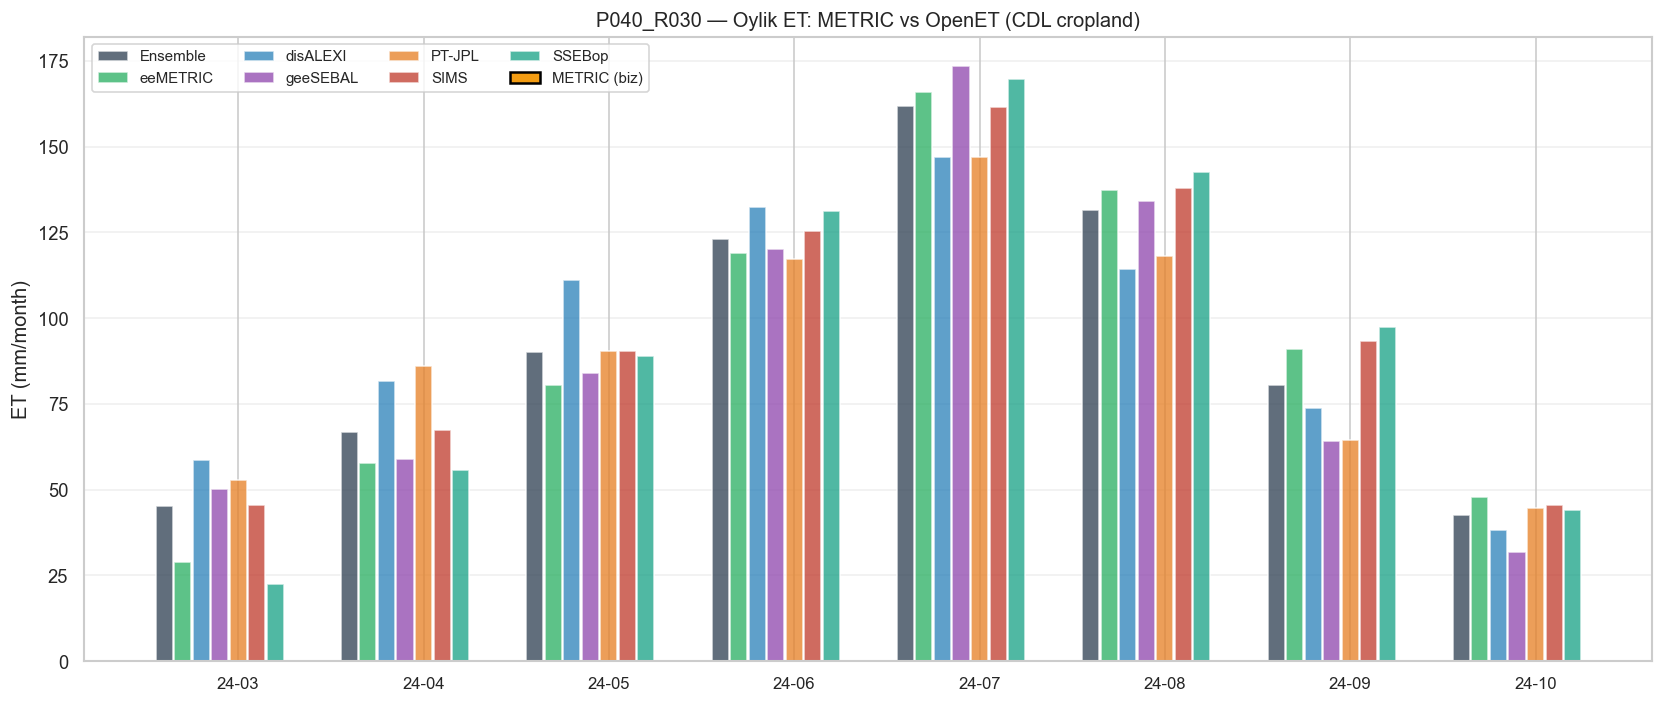

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
months_u = df['month'].unique()
n_models = len(OPENET_MODELS) + 1
bar_w    = 0.8 / n_models
x        = np.arange(len(months_u))

for i, (model, _) in enumerate(OPENET_MODELS.items()):
    vals = []
    for m in months_u:
        sub = df[(df.month == m) & (df.model == model)]['openet'].values
        vals.append(float(sub[0]) if len(sub) and sub[0] is not None else np.nan)
    ax.bar(x + i*bar_w, vals, bar_w*0.92,
           label=model, color=MODEL_COLORS.get(model), alpha=0.75)

metric_vals = []
for m in months_u:
    sub = df[df.month == m]['metric']
    metric_vals.append(float(sub.iloc[0]) if len(sub) and sub.iloc[0] else np.nan)
ax.bar(x + len(OPENET_MODELS)*bar_w, metric_vals, bar_w*0.92,
       label='METRIC (biz)', color=MODEL_COLORS['METRIC'],
       edgecolor='black', linewidth=1.5, zorder=5)

ax.set_xticks(x + bar_w * (n_models/2))
ax.set_xticklabels([m[2:] for m in months_u], fontsize=10)
ax.set_ylabel('ET (mm/month)')
ax.set_title(f'P{TILE_PATH:03d}_R{TILE_ROW:03d} — Oylik ET: METRIC vs OpenET (CDL cropland)')
ax.legend(ncol=4, fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('compare_monthly_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 — Scatter: METRIC vs har bir model

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
stats_rows = []

for idx, (model_name, _) in enumerate(OPENET_MODELS.items()):
    ax  = axes[idx]
    sub = df[df.model == model_name].dropna(subset=['openet', 'metric'])
    x_v = sub['openet'].values.astype(float)
    y_v = sub['metric'].values.astype(float)

    if len(x_v) < 2:
        ax.text(0.5, 0.5, f'n={len(x_v)} — kam', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(model_name)
        continue

    rmse = np.sqrt(mean_squared_error(x_v, y_v))
    mae  = mean_absolute_error(x_v, y_v)
    bias = float(np.mean(y_v - x_v))
    slope, intercept, r_val, *_ = stats.linregress(x_v, y_v)
    r2   = r_val**2

    stats_rows.append({'Model': model_name, 'n': len(x_v),
                       'R2': round(r2, 3), 'RMSE': round(rmse, 2),
                       'MAE': round(mae, 2), 'Bias': round(bias, 2),
                       'Bias_pct': round(100*bias/np.mean(x_v), 1)})

    color = MODEL_COLORS.get(model_name, 'steelblue')
    ax.scatter(x_v, y_v, c=np.arange(len(x_v)), cmap='RdYlGn',
               s=90, edgecolors=color, linewidths=1.2, zorder=3)
    for xi, yi, mo in zip(x_v, y_v, sub['month']):
        ax.annotate(mo[5:], (xi, yi), xytext=(5, 3),
                    textcoords='offset points', fontsize=8, color='gray')
    xr = np.linspace(x_v.min(), x_v.max(), 50)
    ax.plot(xr, slope*xr + intercept, color=color, lw=1.5, ls='--')
    lim = (min(x_v.min(), y_v.min())*0.88, max(x_v.max(), y_v.max())*1.1)
    ax.plot(lim, lim, 'k--', lw=0.8, alpha=0.4)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'{model_name} (mm)', fontsize=9)
    ax.set_ylabel('METRIC (mm)', fontsize=9)
    ax.set_title(model_name, fontsize=11, fontweight='bold', color=color)
    ax.text(0.05, 0.93, f'R2={r2:.2f}  RMSE={rmse:.1f}  Bias={bias:+.1f}',
            transform=ax.transAxes, fontsize=8.5,
            bbox=dict(boxstyle='round', fc='white', alpha=0.75))

axes[-1].set_visible(False)
fig.suptitle(f'METRIC vs OpenET — P{TILE_PATH:03d}_R{TILE_ROW:03d} (CDL cropland)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('compare_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 — Model reytingi

In [ ]:
if stats_rows:
    df_stats = pd.DataFrame(stats_rows).set_index('Model')
    df_stats['Rank_R'] = df_stats['RMSE'].rank() + df_stats['MAE'].rank() + df_stats['R2'].rank(ascending=False)
    df_stats = df_stats.sort_values('Rank_R')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, (col, label, inv) in zip(axes, [('RMSE','RMSE (mm)',True),
                                             ('MAE', 'MAE (mm)', True),
                                             ('R2',  'R2',       False)]):
        colors = [MODEL_COLORS.get(m, 'gray') for m in df_stats.index]
        bars   = ax.barh(df_stats.index, df_stats[col], color=colors, alpha=0.85)
        for bar, v in zip(bars, df_stats[col]):
            ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
                    f'{v:.2f}', va='center', fontsize=9)
        ax.set_xlabel(label); ax.set_title(label)
        if inv:
            ax.invert_yaxis()

    best = df_stats.index[0]
    fig.suptitle(f'Reyting — eng yaxshi: {best}  (P{TILE_PATH:03d}_R{TILE_ROW:03d})',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('compare_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('REYTING:')
    print(df_stats[['n', 'R2', 'RMSE', 'MAE', 'Bias', 'Bias_pct']].to_string())
    print(f'\nMETRIC {best} ga eng yaqin.')

## 4 — Mavsumiy va Heatmap

In [ ]:
seasonal = {'METRIC': df.groupby('month')['metric'].first().sum()}
for model in OPENET_MODELS:
    seasonal[model] = df[df.model == model]['openet'].sum(min_count=1)
df_sea = pd.Series(seasonal, name='ET_season_mm')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

c_list = [MODEL_COLORS.get(m, 'gray') for m in df_sea.index]
bars   = ax1.bar(df_sea.index, df_sea.values, color=c_list)
mi     = list(df_sea.index).index('METRIC')
bars[mi].set_edgecolor('black'); bars[mi].set_linewidth(2)
for b, v in zip(bars, df_sea.values):
    if v and not np.isnan(v):
        ax1.text(b.get_x()+b.get_width()/2, b.get_height()+5, f'{v:.0f}',
                 ha='center', va='bottom', fontsize=9)
ax1.set_ylabel('Mavsumiy ET (mm)')
ax1.set_title('Mavsumiy yigindi')
ax1.tick_params(axis='x', rotation=30)

heat_rows = []
for mo in df['month'].unique():
    sub = df[df.month == mo]
    met = sub['metric'].iloc[0] if len(sub) else None
    for model in OPENET_MODELS:
        row = sub[sub.model == model]['openet'].values
        oe  = float(row[0]) if len(row) and row[0] is not None else None
        heat_rows.append({'Oy': mo[5:], 'Model': model,
                          'diff': (met - oe) if (met and oe) else np.nan})

df_heat = pd.DataFrame(heat_rows).pivot(index='Model', columns='Oy', values='diff')
valid   = df_heat.values[~np.isnan(df_heat.values)]
vmax    = np.max(np.abs(valid)) if len(valid) else 10

if HAS_SNS:
    sns.heatmap(df_heat, ax=ax2, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
                annot=True, fmt='.1f', linewidths=0.5,
                cbar_kws={'label': 'METRIC - OpenET (mm)'})
else:
    im = ax2.imshow(df_heat.values, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')
    ax2.set_xticks(range(len(df_heat.columns))); ax2.set_xticklabels(df_heat.columns)
    ax2.set_yticks(range(len(df_heat.index)));   ax2.set_yticklabels(df_heat.index)
    plt.colorbar(im, ax=ax2, label='METRIC - OpenET (mm)')

ax2.set_title('Oylik farq: METRIC minus OpenET (mm)')
fig.suptitle(f'P{TILE_PATH:03d}_R{TILE_ROW:03d} — Mavsumiy tahlil', fontsize=13)
plt.tight_layout()
plt.savefig('compare_seasonal_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Natijalarni saqlash

In [ ]:
df_wide = df.pivot(index='month', columns='model', values='openet').copy()
df_wide.insert(0, 'METRIC', df.groupby('month')['metric'].first())

out_xlsx = f'METRIC_OpenET_P{TILE_PATH:03d}_R{TILE_ROW:03d}.xlsx'
out_csv  = out_xlsx.replace('.xlsx', '.csv')

with pd.ExcelWriter(out_xlsx, engine='openpyxl') as writer:
    df_wide.round(2).to_excel(writer, sheet_name='Oylik_ET_mm')
    if stats_rows:
        df_stats.drop(columns=['Rank_R'], errors='ignore').to_excel(writer, sheet_name='Statistika')
    df_sea.to_frame().T.to_excel(writer, sheet_name='Mavsumiy')

df_wide.round(2).to_csv(out_csv)
print(f'Saqlandi: {out_xlsx}')
print(f'Saqlandi: {out_csv}')
print(df_wide.round(1).to_string())